# B-Baum mit Visualisierung

- **korrekter Insert- und Delete-Algorithmus** in einer standardisierten Lehrbuch-Variante
- **PowerPoint-Konvention**: Ordnung `k = 2` (min. 2 Schlüssel pro Nicht-Wurzel-Knoten)
- intern umgesetzt mit Parameter `t = 3` (damit `min_keys = t - 1 = 2`)
- echte grafische Knoten mit **Schlüssel-Zellen** und **Pointer-Zellen** `p0, p1, ...`
- Suche mit **Pfadanzeige**
- Löschen mit **Schrittanzeige**
- Validierung der B-Baum-Regeln

## B-Baum-Regeln nach PowerPoint (Ordnung `k = 2`)

| Eigenschaft | Wert |
|---|---:|
| Mindestschlüssel pro Nicht-Wurzel-Knoten | `2` |
| Maximalschlüssel pro Knoten | `4` |
| Kinderzahl bei innerem Knoten | `Schlüsselanzahl + 1` |

Damit sind in dieser Lehrversion Nicht-Wurzel-Knoten mit mindestens 2 und maximal 4 Schlüsseln erlaubt.


<style>
/* Bessere Lesbarkeit im Dark Mode: Notebook-Überschriften */
h1, h2, h3 {
    color: #f8fafc !important;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3 {
    color: #f8fafc !important;
}
</style>


## 1. Optional: Graphviz installieren

Falls der Import fehlschlägt, führe die nächste Zelle einmal aus. Danach Kernel neu starten.


In [42]:
# Nur ausführen, falls graphviz fehlt:
# %pip install graphviz


## 2. Imports


In [43]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Any
from graphviz import Source
from IPython.display import display, Markdown
import copy
import itertools


## 3. Datenstruktur und korrekter B-Baum-Algorithmus


In [44]:
_id_counter = itertools.count(1)

@dataclass
class BTreeNode:
    t: int
    leaf: bool = True
    keys: List[int] = field(default_factory=list)
    children: List['BTreeNode'] = field(default_factory=list)
    uid: int = field(default_factory=lambda: next(_id_counter))

    @property
    def min_keys(self) -> int:
        return self.t - 1

    @property
    def max_keys(self) -> int:
        # PowerPoint-Konvention fuer Ordnung k=2: max. 4 Schluessel pro Knoten.
        return 4

    def is_full(self) -> bool:
        return len(self.keys) == self.max_keys

    def is_overflow(self) -> bool:
        return len(self.keys) > self.max_keys


class BTree:
    def __init__(self, t: int = 3):
        if t < 2:
            raise ValueError("t muss mindestens 2 sein.")
        self.t = t
        self.root = BTreeNode(t=t, leaf=True)
        self._trace: List[Tuple[str, Any]] = []

    def search(self, key: int, node: Optional[BTreeNode] = None, path=None):
        if node is None:
            node = self.root
        if path is None:
            path = []
        i = 0
        while i < len(node.keys) and key > node.keys[i]:
            i += 1
        path.append((node.uid, node.keys.copy(), i))
        if i < len(node.keys) and key == node.keys[i]:
            return True, path
        if node.leaf:
            return False, path
        return self.search(key, node.children[i], path)

    def insert(self, key: int) -> None:
        found, _ = self.search(key)
        if found:
            return
        self._insert_nonfull(self.root, key)

        # Root-Split erst bei echtem Ueberlauf (5 Schluessel bei max=4).
        if self.root.is_overflow():
            s = BTreeNode(t=self.t, leaf=False, children=[self.root])
            self.root = s
            self._split_child(s, 0)

    def _insert_nonfull(self, node: BTreeNode, key: int) -> None:
        i = len(node.keys) - 1
        if node.leaf:
            node.keys.append(0)
            while i >= 0 and key < node.keys[i]:
                node.keys[i + 1] = node.keys[i]
                i -= 1
            node.keys[i + 1] = key
        else:
            while i >= 0 and key < node.keys[i]:
                i -= 1
            i += 1
            self._insert_nonfull(node.children[i], key)
            # Split nach dem Abstieg nur bei Ueberlauf des Kindes.
            if node.children[i].is_overflow():
                self._split_child(node, i)

    def _split_child(self, parent: BTreeNode, index: int) -> None:
        t = self.t
        full = parent.children[index]
        right = BTreeNode(t=t, leaf=full.leaf)
        median = full.keys[t - 1]
        right.keys = full.keys[t:]
        full.keys = full.keys[:t - 1]
        if not full.leaf:
            right.children = full.children[t:]
            full.children = full.children[:t]
        parent.keys.insert(index, median)
        parent.children.insert(index + 1, right)

    def delete(self, key: int, trace: bool = False, policy: str = "standard") -> None:
        self._trace = []
        if trace:
            self._trace.append((f"Start: Lösche {key}.", self.clone()))
        self._delete(self.root, key, trace=trace, policy=policy)
        if len(self.root.keys) == 0 and not self.root.leaf:
            self.root = self.root.children[0]
            if trace:
                self._trace.append(("Die Wurzel war leer: Das einzige Kind wird neue Wurzel.", self.clone()))
        if trace:
            self._trace.append((f"Fertig: delete({key}) ist abgeschlossen.", self.clone()))

    def delete_with_steps(self, key: int, policy: str = "standard") -> None:
        self.delete(key, trace=True, policy=policy)
        for nr, (text, tree_snapshot) in enumerate(self._trace, start=1):
            display(Markdown(f"### Schritt {nr}: {text}"))
            display(tree_snapshot.draw(title=text))

    def _delete(self, node: BTreeNode, key: int, trace: bool = False, policy: str = "standard") -> None:
        t = self.t
        i = 0
        while i < len(node.keys) and key > node.keys[i]:
            i += 1

        if i < len(node.keys) and node.keys[i] == key:
            if node.leaf:
                node.keys.pop(i)
                if trace:
                    self._trace.append((f"{key} wurde direkt aus einem Blatt entfernt.", self.clone()))
                return

            left = node.children[i]
            right = node.children[i + 1]
            if len(left.keys) >= t:
                pred = self._max_key(left)
                node.keys[i] = pred
                if trace:
                    self._trace.append((f"{key} liegt im inneren Knoten. Ersetze durch Vorgänger {pred}.", self.clone()))
                self._delete(left, pred, trace=trace, policy=policy)
            elif len(right.keys) >= t:
                succ = self._min_key(right)
                node.keys[i] = succ
                if trace:
                    self._trace.append((f"{key} liegt im inneren Knoten. Ersetze durch Nachfolger {succ}.", self.clone()))
                self._delete(right, succ, trace=trace, policy=policy)
            else:
                if trace:
                    self._trace.append((f"Beide Nachbarkinder haben nur Mindestbelegung. Merge um {key} herum.", self.clone()))
                self._merge_children(node, i)
                if trace:
                    self._trace.append((f"Nach Merge liegt {key} im zusammengeführten Kind.", self.clone()))
                self._delete(left, key, trace=trace, policy=policy)
            return

        if node.leaf:
            if trace:
                self._trace.append((f"{key} wurde nicht gefunden; Suche endet im Blatt.", self.clone()))
            return

        child_index = i
        child = node.children[child_index]
        if len(child.keys) == t - 1:
            if trace:
                self._trace.append((f"Vor dem Abstieg hat Kind p{child_index} nur Mindestbelegung. Rebalancing nötig.", self.clone()))
            child_index = self._fix_child_before_descent(node, child_index, trace=trace, policy=policy)
        self._delete(node.children[child_index], key, trace=trace, policy=policy)

    def _fix_child_before_descent(
        self,
        parent: BTreeNode,
        index: int,
        trace: bool = False,
        policy: str = "standard",
    ) -> int:
        t = self.t

        # Folienmodus: Wenn linkes Geschwister nur Mindestbelegung hat,
        # wird bevorzugt mit links gemerged (wie im PPT-Hauptbeispiel).
        if policy == "ppt" and index > 0 and len(parent.children[index - 1].keys) == t - 1:
            self._merge_children(parent, index - 1)
            if trace:
                self._trace.append((f"PPT-Modus: Merge mit linkem Geschwister für p{index}.", self.clone()))
            return index - 1

        if index > 0 and len(parent.children[index - 1].keys) >= t:
            self._borrow_from_prev(parent, index)
            if trace:
                self._trace.append((f"Redistribute: Kind p{index} leiht einen Schlüssel vom linken Geschwister.", self.clone()))
            return index
        if index < len(parent.children) - 1 and len(parent.children[index + 1].keys) >= t:
            self._borrow_from_next(parent, index)
            if trace:
                self._trace.append((f"Redistribute: Kind p{index} leiht einen Schlüssel vom rechten Geschwister.", self.clone()))
            return index
        if index < len(parent.children) - 1:
            self._merge_children(parent, index)
            if trace:
                self._trace.append((f"Merge: Kind p{index} wurde mit rechtem Geschwister zusammengeführt.", self.clone()))
            return index
        self._merge_children(parent, index - 1)
        if trace:
            self._trace.append((f"Merge: Kind p{index} wurde mit linkem Geschwister zusammengeführt.", self.clone()))
        return index - 1

    def _borrow_from_prev(self, parent: BTreeNode, index: int) -> None:
        child = parent.children[index]
        sibling = parent.children[index - 1]
        child.keys.insert(0, parent.keys[index - 1])
        if not child.leaf:
            child.children.insert(0, sibling.children.pop())
        parent.keys[index - 1] = sibling.keys.pop()

    def _borrow_from_next(self, parent: BTreeNode, index: int) -> None:
        child = parent.children[index]
        sibling = parent.children[index + 1]
        child.keys.append(parent.keys[index])
        if not child.leaf:
            child.children.append(sibling.children.pop(0))
        parent.keys[index] = sibling.keys.pop(0)

    def _merge_children(self, parent: BTreeNode, index: int) -> None:
        left = parent.children[index]
        right = parent.children[index + 1]
        left.keys.append(parent.keys.pop(index))
        left.keys.extend(right.keys)
        if not left.leaf:
            left.children.extend(right.children)
        parent.children.pop(index + 1)

    def _max_key(self, node: BTreeNode) -> int:
        while not node.leaf:
            node = node.children[-1]
        return node.keys[-1]

    def _min_key(self, node: BTreeNode) -> int:
        while not node.leaf:
            node = node.children[0]
        return node.keys[0]

    def clone(self) -> 'BTree':
        new_tree = BTree(self.t)
        new_tree.root = copy.deepcopy(self.root)
        return new_tree


## 4. Textausgabe, Validierung und grafische Darstellung


In [45]:
def _escape(s: str) -> str:
    return str(s).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


def _node_label(
    node: BTreeNode,
    invalid: bool = False,
    active_pointer: Optional[int] = None,
    active_key: Optional[int] = None,
) -> str:
    """Erzeugt eine HTML-ähnliche Graphviz-Tabelle für einen B-Baum-Knoten.

    Didaktische Idee:
    - gelbe Zellen = Schlüssel
    - blaue Zellen = Pointer / Verweise auf Kindknoten
    - orange Pointer-Zelle = dieser Pointer wird im aktuellen Suchschritt benutzt
    - grüne Schlüssel-Zelle = gesuchter Schlüssel wurde hier gefunden
    """
    title = "Blatt" if node.leaf else "Innerer Knoten"
    border_color = "#b91c1c" if invalid else "#2f3b4c"
    bg = "#fff7ed" if invalid else "#ffffff"

    html_cells = [
        f'<TR><TD BGCOLOR="{bg}" COLSPAN="{2 * len(node.keys) + 1}" BORDER="1"><B>{title}</B></TD></TR>',
        '<TR>'
    ]
    for i, key in enumerate(node.keys):
        ptr_bg = "#fb923c" if active_pointer == i else "#e8eef7"
        key_bg = "#bbf7d0" if active_key == key else "#fff4d6"
        html_cells.append(f'<TD PORT="p{i}" BGCOLOR="{ptr_bg}"><B>p{i}</B></TD>')
        html_cells.append(f'<TD BGCOLOR="{key_bg}"><B>{_escape(key)}</B></TD>')

    last_i = len(node.keys)
    ptr_bg = "#fb923c" if active_pointer == last_i else "#e8eef7"
    html_cells.append(f'<TD PORT="p{last_i}" BGCOLOR="{ptr_bg}"><B>p{last_i}</B></TD>')
    html_cells.append('</TR>')
    body = ''.join(html_cells)
    return f'<<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="0" CELLPADDING="8" COLOR="{border_color}">{body}</TABLE>>'


class BTree(BTree):
    def print_tree(self) -> str:
        lines = []
        queue = [(self.root, 0)]
        current_level = 0
        parts = []
        while queue:
            node, level = queue.pop(0)
            if level != current_level:
                lines.append(f"Level {current_level}: " + " | ".join(parts))
                parts = []
                current_level = level
            parts.append(str(node.keys))
            if not node.leaf:
                for child in node.children:
                    queue.append((child, level + 1))
        lines.append(f"Level {current_level}: " + " | ".join(parts))
        return "\n".join(lines)

    def validate(self) -> Tuple[bool, List[str]]:
        errors = []
        leaf_depths = []

        def walk(node: BTreeNode, depth: int, is_root: bool, low, high):
            if node.keys != sorted(node.keys):
                errors.append(f"Knoten {node.uid}: Schlüssel sind nicht sortiert: {node.keys}")
            for key in node.keys:
                if low is not None and key <= low:
                    errors.append(f"Knoten {node.uid}: Schlüssel {key} ist <= untere Grenze {low}")
                if high is not None and key >= high:
                    errors.append(f"Knoten {node.uid}: Schlüssel {key} ist >= obere Grenze {high}")
            if is_root:
                if not node.leaf and len(node.keys) == 0:
                    errors.append("Wurzel ist innerer Knoten ohne Schlüssel.")
                if len(node.keys) > node.max_keys:
                    errors.append(f"Wurzel hat zu viele Schlüssel: {node.keys}")
            else:
                if len(node.keys) < node.min_keys:
                    errors.append(f"Knoten {node.uid}: Unterlauf, zu wenige Schlüssel: {node.keys}")
                if len(node.keys) > node.max_keys:
                    errors.append(f"Knoten {node.uid}: Überlauf, zu viele Schlüssel: {node.keys}")
            if node.leaf:
                leaf_depths.append(depth)
                if node.children:
                    errors.append(f"Blatt {node.uid} hat trotzdem Kinder.")
            else:
                if len(node.children) != len(node.keys) + 1:
                    errors.append(f"Knoten {node.uid}: {len(node.keys)} Schlüssel, aber {len(node.children)} Kinder.")
                bounds = [low] + node.keys + [high]
                for i, child in enumerate(node.children):
                    walk(child, depth + 1, False, bounds[i], bounds[i + 1])

        walk(self.root, 0, True, None, None)
        if len(set(leaf_depths)) > 1:
            errors.append(f"Nicht alle Blätter liegen auf gleicher Höhe: {leaf_depths}")
        return len(errors) == 0, errors

    def _path_details(self, key: int):
        """Liefert Suchpfad inklusive Knoten-UID, gewähltem Pointer und gefundenem Schlüssel."""
        details = []
        node = self.root
        while True:
            i = 0
            while i < len(node.keys) and key > node.keys[i]:
                i += 1

            found_here = i < len(node.keys) and key == node.keys[i]
            details.append({
                "uid": node.uid,
                "keys": node.keys.copy(),
                "pointer": None if found_here else i,
                "found_key": key if found_here else None,
                "leaf": node.leaf,
            })

            if found_here:
                return True, details
            if node.leaf:
                return False, details
            node = node.children[i]

    def to_dot(
        self,
        title: Optional[str] = None,
        highlight_nodes: Optional[List[int]] = None,
        invalid_nodes: Optional[List[int]] = None,
        highlight_edges: Optional[List[Tuple[int, int]]] = None,
        active_pointers: Optional[dict] = None,
        active_keys: Optional[dict] = None,
    ) -> str:
        highlight_nodes = set(highlight_nodes or [])
        invalid_nodes = set(invalid_nodes or [])
        highlight_edges = set(highlight_edges or [])
        active_pointers = active_pointers or {}
        active_keys = active_keys or {}

        lines = [
            'digraph BTree {',
            '  graph [rankdir=TB, bgcolor="transparent", nodesep="0.6", ranksep="0.8"];',
            '  node [shape=plain, fontname="Arial"];',
            '  edge [color="#1f2937", arrowsize="0.8", fontname="Arial"];'
        ]
        if title:
            title_html = _escape(title)
            lines.append(
                '  labelloc="t"; '
                'label=<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="8" COLOR="#334155">'
                f'<TR><TD BGCOLOR="#111827"><FONT COLOR="#f8fafc" POINT-SIZE="22"><B>{title_html}</B></FONT></TD></TR>'
                '</TABLE>>;'
            )

        def walk(node: BTreeNode):
            invalid = node.uid in invalid_nodes
            label = _node_label(
                node,
                invalid=invalid,
                active_pointer=active_pointers.get(node.uid),
                active_key=active_keys.get(node.uid),
            )
            pen = '4' if node.uid in highlight_nodes else '1'
            color = '#2563eb' if node.uid in highlight_nodes else '#2f3b4c'
            lines.append(f'  n{node.uid} [label={label}, penwidth={pen}, color="{color}"];')
            if not node.leaf:
                for i, child in enumerate(node.children):
                    walk(child)
                    edge_pair = (node.uid, child.uid)
                    if edge_pair in highlight_edges:
                        lines.append(
                            f'  n{node.uid}:p{i}:s -> n{child.uid}:n '
                            f'[color="#ef4444", penwidth=3, label="p{i}", fontcolor="#ef4444"];'
                        )
                    else:
                        lines.append(f'  n{node.uid}:p{i}:s -> n{child.uid}:n;')

        walk(self.root)
        lines.append('}')
        return "\n".join(lines)

    def draw(
        self,
        title: Optional[str] = None,
        highlight_nodes: Optional[List[int]] = None,
        invalid_nodes: Optional[List[int]] = None,
        highlight_edges: Optional[List[Tuple[int, int]]] = None,
        active_pointers: Optional[dict] = None,
        active_keys: Optional[dict] = None,
    ):
        return Source(self.to_dot(
            title=title,
            highlight_nodes=highlight_nodes,
            invalid_nodes=invalid_nodes,
            highlight_edges=highlight_edges,
            active_pointers=active_pointers,
            active_keys=active_keys,
        ))

    def show(self, title: Optional[str] = None):
        display(self.draw(title=title))
        ok, errors = self.validate()
        if ok:
            display(Markdown("✅ **B-Baum-Regeln erfüllt.**"))
        else:
            display(Markdown("❌ **B-Baum-Regeln verletzt:**\n" + "\n".join(f"- {e}" for e in errors)))

    def show_search(self, key: int):
        found, details = self._path_details(key)
        highlight_nodes = [d["uid"] for d in details]
        active_pointers = {d["uid"]: d["pointer"] for d in details if d["pointer"] is not None}
        active_keys = {d["uid"]: d["found_key"] for d in details if d["found_key"] is not None}

        # Kanten des tatsächlichen Suchpfads bestimmen.
        highlight_edges = []
        def find_node_by_uid(node: BTreeNode, uid: int):
            if node.uid == uid:
                return node
            for child in node.children:
                result = find_node_by_uid(child, uid)
                if result:
                    return result
            return None

        for current, nxt in zip(details, details[1:]):
            parent = find_node_by_uid(self.root, current["uid"])
            if parent and current["pointer"] is not None:
                child = parent.children[current["pointer"]]
                highlight_edges.append((parent.uid, child.uid))

        display(Markdown(f"### Suche nach `{key}` → {'gefunden' if found else 'nicht gefunden'}"))
        explanation = []
        for nr, d in enumerate(details, start=1):
            keys = d["keys"]
            if d["found_key"] is not None:
                explanation.append(f"**Schritt {nr}:** Knoten `{keys}` → Schlüssel `{key}` wurde hier gefunden.")
            elif d["leaf"]:
                explanation.append(f"**Schritt {nr}:** Knoten `{keys}` → Blatt erreicht, `{key}` ist nicht enthalten.")
            else:
                explanation.append(f"**Schritt {nr}:** Knoten `{keys}` → gehe über Pointer `p{d['pointer']}`.")
        display(Markdown("\n\n".join(explanation)))
        display(self.draw(
            title=f"Suchpfad für {key}: rote Pfeile + orange Pointer-Zellen",
            highlight_nodes=highlight_nodes,
            highlight_edges=highlight_edges,
            active_pointers=active_pointers,
            active_keys=active_keys,
        ))

    def show_search_steps(self, key: int):
        """Zeigt den Suchpfad schrittweise: erst Wurzel, dann nächster Pointer, usw."""
        found, details = self._path_details(key)
        display(Markdown(f"## Schrittweise Suche nach `{key}`"))
        for step in range(1, len(details) + 1):
            partial = details[:step]
            highlight_nodes = [d["uid"] for d in partial]
            active_pointers = {d["uid"]: d["pointer"] for d in partial if d["pointer"] is not None}
            active_keys = {d["uid"]: d["found_key"] for d in partial if d["found_key"] is not None}

            highlight_edges = []
            uid_to_node = {}
            def collect(node):
                uid_to_node[node.uid] = node
                for child in node.children:
                    collect(child)
            collect(self.root)

            for current, nxt in zip(partial, partial[1:]):
                parent = uid_to_node[current["uid"]]
                if current["pointer"] is not None:
                    child = parent.children[current["pointer"]]
                    highlight_edges.append((parent.uid, child.uid))

            d = partial[-1]
            if d["found_key"] is not None:
                text = f"Schritt {step}: Schlüssel `{key}` wurde im Knoten `{d['keys']}` gefunden."
            elif d["leaf"]:
                text = f"Schritt {step}: Blatt `{d['keys']}` erreicht. `{key}` wurde nicht gefunden."
            else:
                text = f"Schritt {step}: Im Knoten `{d['keys']}` wird Pointer `p{d['pointer']}` gewählt."

            display(Markdown(f"### {text}"))
            display(self.draw(
                title=text,
                highlight_nodes=highlight_nodes,
                highlight_edges=highlight_edges,
                active_pointers=active_pointers,
                active_keys=active_keys,
            ))


## 5. Übung 1 – B-Baum aufbauen (Schritt für Schritt)

Einfügereihenfolge aus der Folie: `10, 20, 5, 30, 25`.


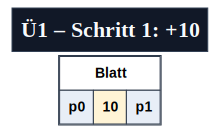

✅ **B-Baum-Regeln erfüllt.**

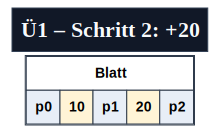

✅ **B-Baum-Regeln erfüllt.**

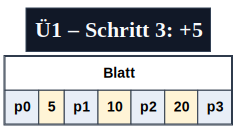

✅ **B-Baum-Regeln erfüllt.**

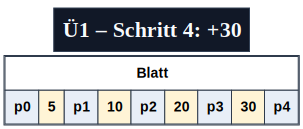

✅ **B-Baum-Regeln erfüllt.**

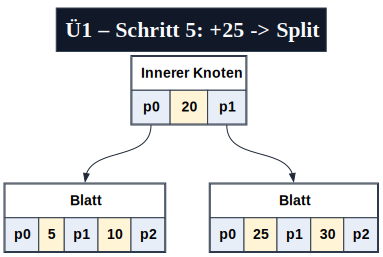

✅ **B-Baum-Regeln erfüllt.**

In [46]:
u1 = BTree(t=3)

u1.insert(10)
u1.show("Ü1 – Schritt 1: +10")

u1.insert(20)
u1.show("Ü1 – Schritt 2: +20")

u1.insert(5)
u1.show("Ü1 – Schritt 3: +5")

u1.insert(30)
u1.show("Ü1 – Schritt 4: +30")

u1.insert(25)
u1.show("Ü1 – Schritt 5: +25 -> Split")


## 6. Übung 2 – B-Baum mit zwei Splits (Zwischenzustände A–F)

Aufbau gemäß Folie mit den Zuständen A bis F.


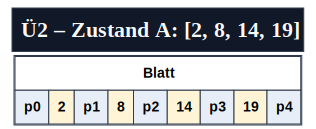

✅ **B-Baum-Regeln erfüllt.**

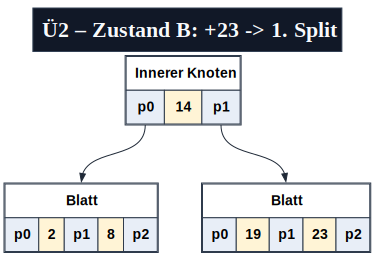

✅ **B-Baum-Regeln erfüllt.**

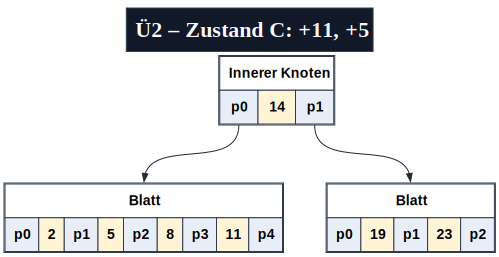

✅ **B-Baum-Regeln erfüllt.**

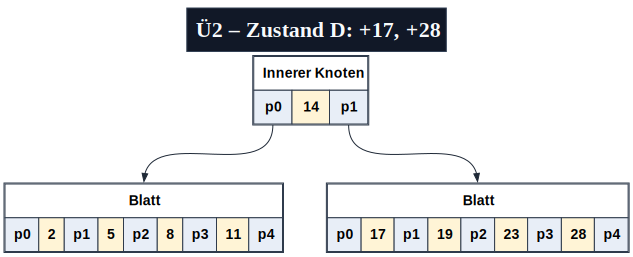

✅ **B-Baum-Regeln erfüllt.**

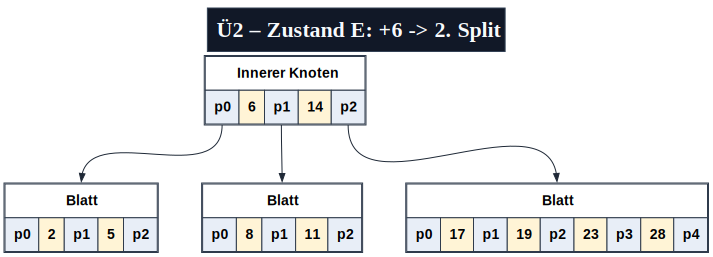

✅ **B-Baum-Regeln erfüllt.**

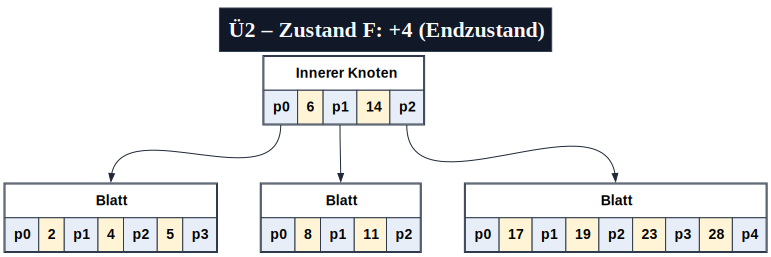

✅ **B-Baum-Regeln erfüllt.**

In [47]:
b = BTree(t=3)

# Zustand A: Start (nach +19)
for v in [8, 14, 2, 19]:
    b.insert(v)
b.show("Ü2 – Zustand A: [2, 8, 14, 19]")

# Zustand B: +23 -> 1. Split
b.insert(23)
b.show("Ü2 – Zustand B: +23 -> 1. Split")

# Zustand C: +11, +5
b.insert(11)
b.insert(5)
b.show("Ü2 – Zustand C: +11, +5")

# Zustand D: +17, +28
b.insert(17)
b.insert(28)
b.show("Ü2 – Zustand D: +17, +28")

# Zustand E: +6 -> 2. Split
b.insert(6)
b.show("Ü2 – Zustand E: +6 -> 2. Split")

# Zustand F: +4 (Endzustand)
b.insert(4)
b.show("Ü2 – Zustand F: +4 (Endzustand)")


## 7. Suche mit farbigem Pfad

Orange Pointer-Zellen zeigen, welcher Verweis im aktuellen Knoten gewählt wird. Rote Pfeile zeigen den tatsächlich verfolgten Suchpfad.


### Suche nach `17` → gefunden

**Schritt 1:** Knoten `[6, 14]` → gehe über Pointer `p2`.

**Schritt 2:** Knoten `[17, 19, 23, 28]` → Schlüssel `17` wurde hier gefunden.

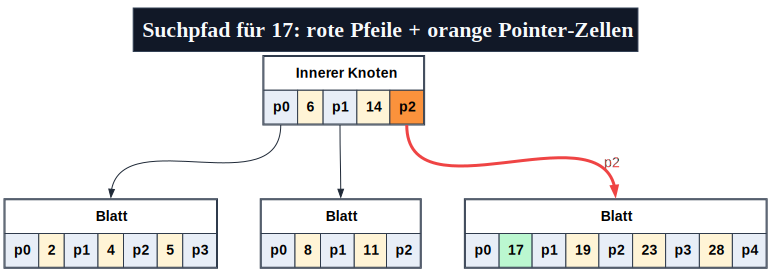

### Suche nach `13` → nicht gefunden

**Schritt 1:** Knoten `[6, 14]` → gehe über Pointer `p1`.

**Schritt 2:** Knoten `[8, 11]` → Blatt erreicht, `13` ist nicht enthalten.

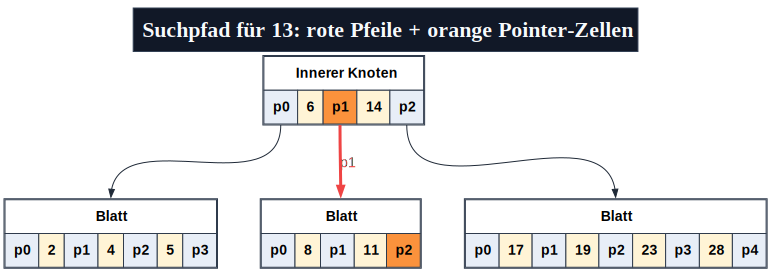

## Schrittweise Suche nach `17`

### Schritt 1: Im Knoten `[6, 14]` wird Pointer `p2` gewählt.

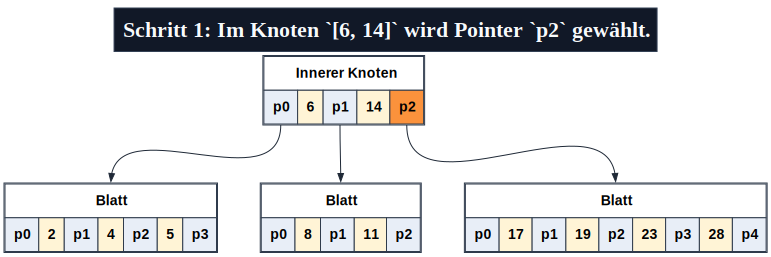

### Schritt 2: Schlüssel `17` wurde im Knoten `[17, 19, 23, 28]` gefunden.

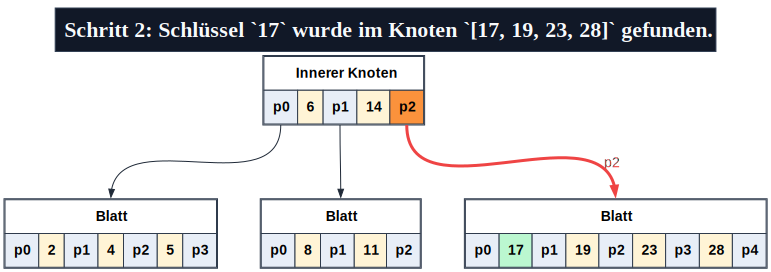

In [48]:
# Gesamtansicht des Suchpfads
b.show_search(17)
b.show_search(13)

# Schritt-für-Schritt-Darstellung für die Vorlesung
b.show_search_steps(17)


## 8. Löschen mit Rebalancing (Folienmodus)

Die Methode `delete_with_steps()` zeigt die wichtigsten Zwischenschritte:

- Schlüssel entfernen
- vor dem Abstieg prüfen, ob ein Kind nur Mindestbelegung hat
- ggf. **Redistribute/Borrow**
- ggf. **Merge**
- Wurzel schrumpfen, falls nötig


### Schritt 1: Start: Lösche 4.

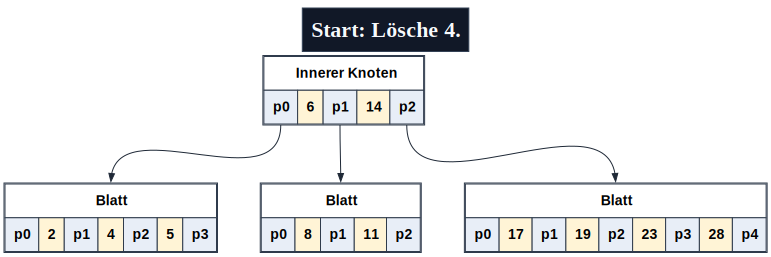

### Schritt 2: 4 wurde direkt aus einem Blatt entfernt.

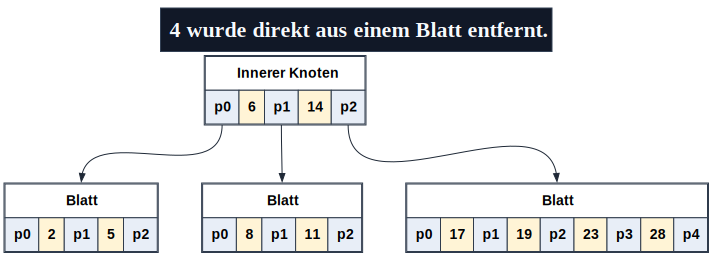

### Schritt 3: Fertig: delete(4) ist abgeschlossen.

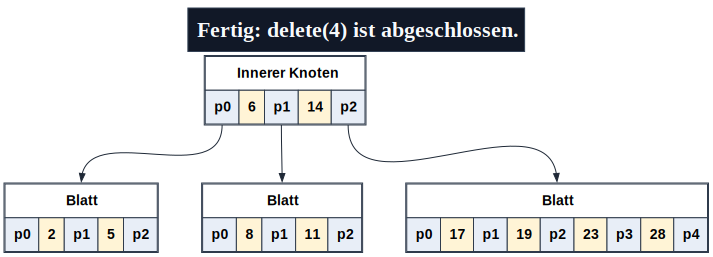

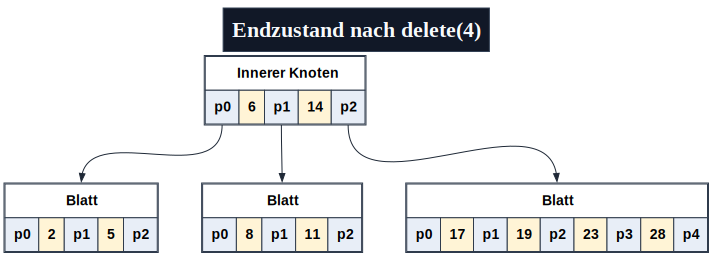

✅ **B-Baum-Regeln erfüllt.**

### Schritt 1: Start: Lösche 19.

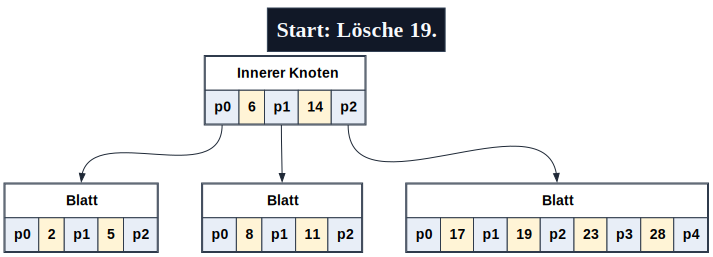

### Schritt 2: 19 wurde direkt aus einem Blatt entfernt.

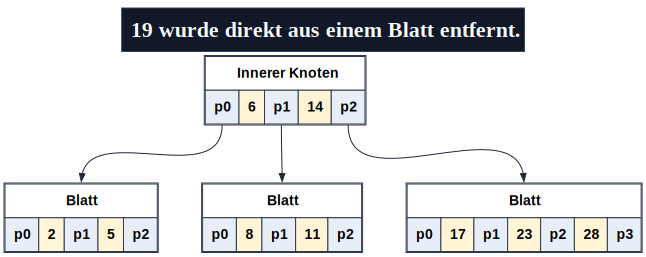

### Schritt 3: Fertig: delete(19) ist abgeschlossen.

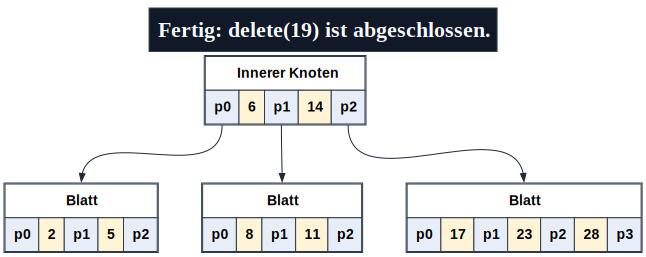

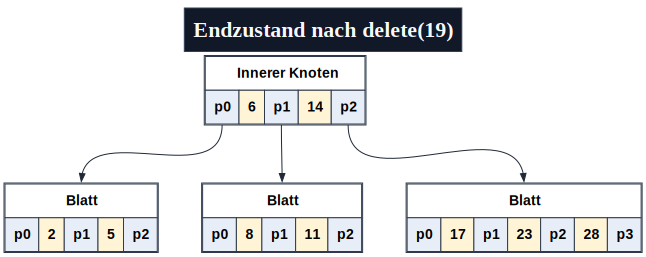

✅ **B-Baum-Regeln erfüllt.**

### Schritt 1: Start: Lösche 11.

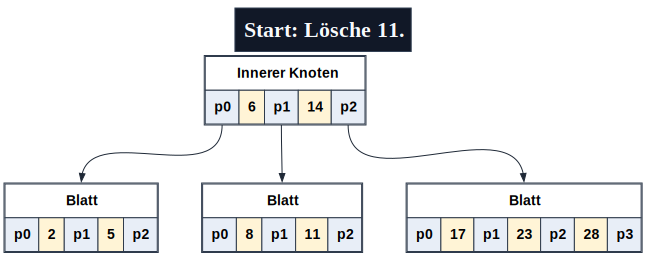

### Schritt 2: Vor dem Abstieg hat Kind p1 nur Mindestbelegung. Rebalancing nötig.

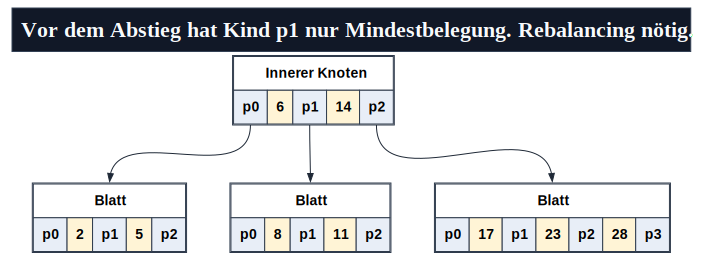

### Schritt 3: PPT-Modus: Merge mit linkem Geschwister für p1.

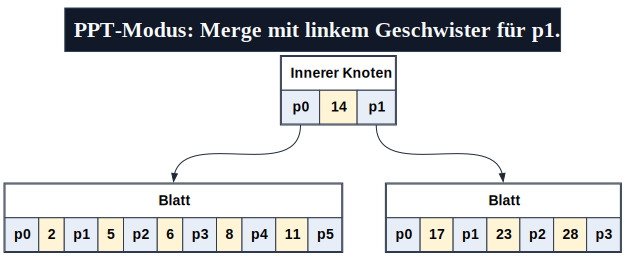

### Schritt 4: 11 wurde direkt aus einem Blatt entfernt.

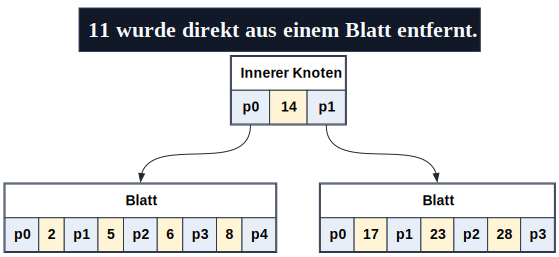

### Schritt 5: Fertig: delete(11) ist abgeschlossen.

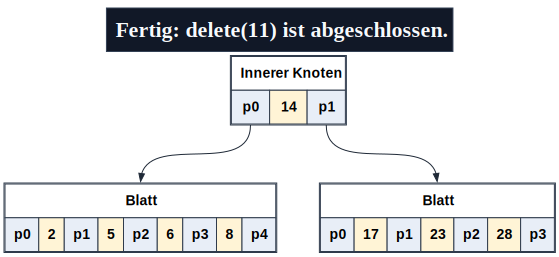

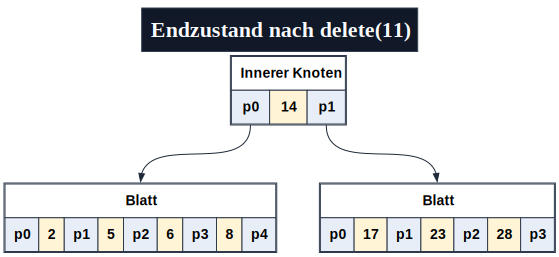

✅ **B-Baum-Regeln erfüllt.**

In [49]:
for v in [4, 19, 11]:
    b.delete_with_steps(v, policy="ppt")
    b.show(f"Endzustand nach delete({v})")


## 9. Kompakte Endausgabe


In [50]:
print(b.print_tree())
ok, errors = b.validate()
print("gültig:", ok)
if errors:
    print("Fehler:")
    for e in errors:
        print("-", e)


Level 0: [14]
Level 1: [2, 5, 6, 8] | [17, 23, 28]
gültig: True


## 10. Hinweise

### Warum entsteht beim Löschen manchmal ein Problem?

Beim Löschen kann ein Knoten zu wenige Schlüssel bekommen. Das nennt man **Underflow**.

Bei der Folien-Konvention `k = 2` (hier intern `t = 3`) gilt:

- Nicht-Wurzel-Knoten brauchen mindestens `2` Schlüssel.
- Ein leerer Blattknoten ist daher ungültig.

### Wie wird das repariert?

1. **Borrow / Redistribute:** Ein Nachbarknoten hat genug Schlüssel und gibt einen ab.
2. **Merge:** Beide Nachbarn haben nur Mindestbelegung. Dann werden zwei Knoten mit einem Trennschlüssel aus dem Elternknoten zusammengeführt.

### Merksatz

> Beim B-Baum löscht man nicht einfach nur einen Wert. Man hält während des Abstiegs die Struktur stabil, damit am Ende wieder alle B-Baum-Regeln erfüllt sind.
